<a href="https://colab.research.google.com/github/RoihansLab/Machine-Learning-Projects/blob/main/10_End_to_End_Retail_Demand_Forecasting/10_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning Model for 10_End_to_End_Retail_Demand_Forecasting.**

## **1. Import Libraries Module**

In [26]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from xgboost import XGBRegressor
import optuna
import pickle

## **2. Load the Datasets**

In [27]:
df = pd.read_csv("/content/demand_forecasting.csv")
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84


In [28]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [29]:
feature = [
    "Price",
    "Competitor Pricing",
    "Discount",
    "Inventory Level",
    "Category",
    "Promotion"
]

feature

['Price',
 'Competitor Pricing',
 'Discount',
 'Inventory Level',
 'Category',
 'Promotion']

In [30]:
feature

['Price',
 'Competitor Pricing',
 'Discount',
 'Inventory Level',
 'Category',
 'Promotion']

In [31]:
target = "Demand"

In [32]:
X = df[feature].copy()
X

,Price,Competitor Pricing,Discount,Inventory Level,Category,Promotion
0,72.72,85.73,5,195,Electronics,0
1,80.16,92.02,15,117,Clothing,1
2,62.94,60.08,10,247,Clothing,1
3,87.63,85.19,10,139,Electronics,0
4,54.41,51.63,0,152,Groceries,0
...,...,...,...,...,...,...
75995,29.80,32.23,5,233,Toys,0
75996,42.92,40.73,5,137,Toys,0
75997,17.81,19.41,10,197,Clothing,0
75998,151.72,143.71,0,125,Furniture,0


In [33]:
y = df[target]
y

,Demand
0,115
1,229
2,157
3,52
4,59
...,...
75995,64
75996,137
75997,68
75998,84


Label Encoder

In [34]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount',
       'Weather Condition', 'Promotion', 'Competitor Pricing', 'Seasonality',
       'Epidemic', 'Demand'],
      dtype='object')

In [35]:
le_category = LabelEncoder()
X["Category"]= le_category.fit_transform(X["Category"])

X

,Price,Competitor Pricing,Discount,Inventory Level,Category,Promotion
0,72.72,85.73,5,195,1,0
1,80.16,92.02,15,117,0,1
2,62.94,60.08,10,247,0,1
3,87.63,85.19,10,139,1,0
4,54.41,51.63,0,152,3,0
...,...,...,...,...,...,...
75995,29.80,32.23,5,233,4,0
75996,42.92,40.73,5,137,4,0
75997,17.81,19.41,10,197,0,0
75998,151.72,143.71,0,125,2,0


In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
X_train.shape , y_train.shape

((60800, 6), (60800,))

In [38]:
X_test.shape, y_test.shape

((15200, 6), (15200,))

In [39]:
xgb = XGBRegressor(objective="reg:squarederror", n_jobs = -1 , random_state=42)


Aiming the **best** Performance with Hyperparameter Tuning

In [40]:
param_dict = {
    "n_estimators" : [200, 300, 500],
    "max_depth" : [3, 4, 6, 8],
    "learning_rate" : [0.01, 0.02, 0.1],
    "subsample" : [0.7, 0.8, 1.0],
    "colsample_bytree" : [0.7, 0.8, 1.0],
    "min_child_weight" : [1, 3, 5],
}

In [41]:
random_search = RandomizedSearchCV(
    estimator = xgb,
    param_distributions = param_dict,
    n_iter = 25,
    scoring = "neg_mean_squared_error",
    cv = 3,
    verbose = 1,
    n_jobs = -1
)

In [42]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 25 candidates, totalling 75 fits


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=25, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.02, 0.1],
                                        'max_depth': [3, 4, 6, 8],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [200, 300, 500],
                                        'subsample': [0.7, 0.8, 1.0]},
                   scoring='neg_mean_squared_error', verbose=1)

In [43]:
random_search.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.02,
 'colsample_bytree': 1.0}

In [45]:
best_model = random_search.best_estimator_

In [55]:
# 1. Usir paksa dua kolom siluman kalau mereka masih nempel di X_test
X_test = X_test.drop(columns=['Predicted Demand', 'Actual Demand'], errors='ignore')

# 2. Baru hajar tebakannya!
y_pred = best_model.predict(X_test)

# 3. Tampilin biar lu yakin y_pred-nya beneran udah ada isinya
print("Berhasil nebak! Ini 5 hasil tebakan pertamanya:", y_pred[:10])

Berhasil nebak! Ini 5 hasil tebakan pertamanya: [ 83.40923   70.8384    37.31365  107.40641   79.29456  101.22902
 108.972725 114.52555  133.37404  133.56409 ]


In [56]:
# Bikin tabel perbandingan Asli vs Prediksi
hasil_df = pd.DataFrame({
    "Kenyataan (Actual)": y_test,
    "Tebakan (Predicted)": y_pred.round() # Dibulatkan, karena Demand barang nggak mungkin koma
})

# Liat 10 baris pertama
print(hasil_df.head(10))

       Kenyataan (Actual)  Tebakan (Predicted)
53731                 111                 83.0
61112                  81                 71.0
72074                  37                 37.0
56928                 152                107.0
20979                 101                 79.0
59697                 137                101.0
51092                 127                109.0
70258                 163                115.0
51086                 164                133.0
1768                  111                134.0


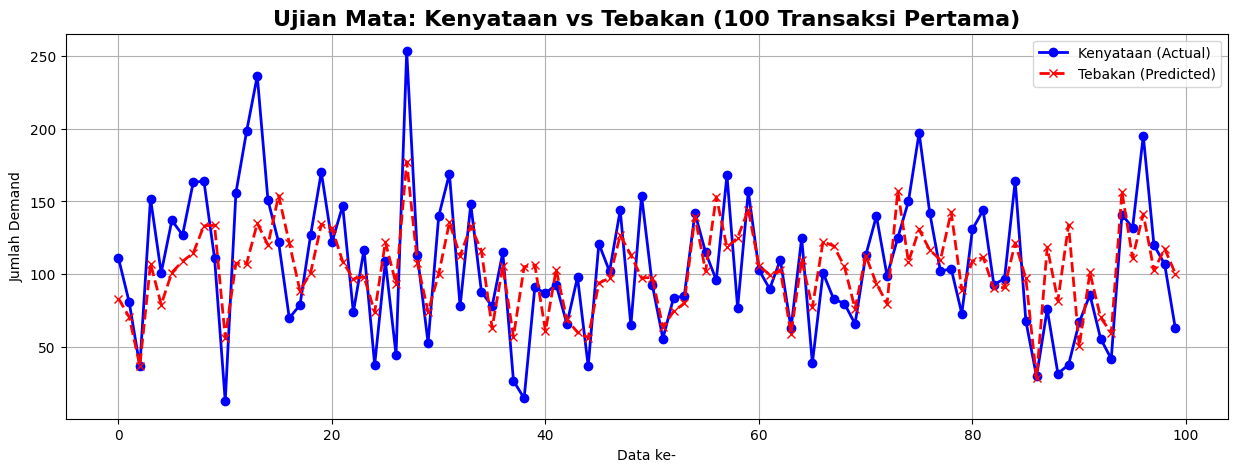

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

# Bikin garis biru buat Kenyataan, garis merah putus-putus buat Tebakan
plt.plot(y_test.values[:100], label="Kenyataan (Actual)", color="blue", marker="o", linewidth=2)
plt.plot(y_pred[:100], label="Tebakan (Predicted)", color="red", linestyle="dashed", marker="x", linewidth=2)

plt.title("Ujian Mata: Kenyataan vs Tebakan (100 Transaksi Pertama)", fontsize=16, fontweight="bold")
plt.ylabel("Jumlah Demand")
plt.xlabel("Data ke-")
plt.legend()
plt.grid(True)
plt.show()

In [58]:
# 1. Suruh mesin nebak ulang soal latihannya (Data Training)
y_pred_train = best_model.predict(X_train)

# 2. Ngadu nilai R2 Score (Akurasi)
print("=== CEK KASTA MESIN LU: JAGO KANDANG ATAU NGGAK? ===")
print(f"R2 Score (Data Latihan/Train) : {r2_score(y_train, y_pred_train):.3f}")
print(f"R2 Score (Data Ujian/Test)    : {r2_score(y_test, y_pred):.3f}")
print("-" * 50)

# 3. Ngadu nilai MAE (Berapa pcs melesetnya)
print(f"Meleset di Latihan (MAE Train): {mean_absolute_error(y_train, y_pred_train):.2f} pcs")
print(f"Meleset di Ujian (MAE Test)   : {mean_absolute_error(y_test, y_pred):.2f} pcs")

=== CEK KASTA MESIN LU: JAGO KANDANG ATAU NGGAK? ===
R2 Score (Data Latihan/Train) : 0.469
R2 Score (Data Ujian/Test)    : 0.428
--------------------------------------------------
Meleset di Latihan (MAE Train): 26.11 pcs
Meleset di Ujian (MAE Test)   : 27.13 pcs


In [61]:
best_model.feature_importances_

array([0.04062534, 0.0116261 , 0.00921372, 0.00910219, 0.18382886,
       0.74560386], dtype=float32)

In [64]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
Promotion,0.745604
Category,0.183829
Price,0.040625
Competitor Pricing,0.011626
Discount,0.009214
Inventory Level,0.009102


<Axes: title={'center': 'Feature Importance'}>

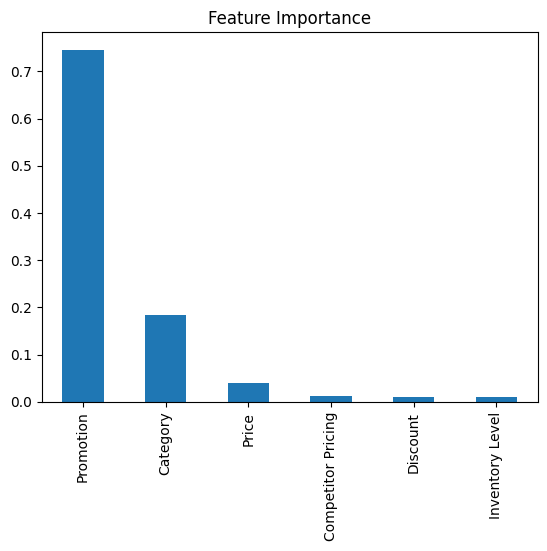

In [67]:
feature_importance.plot(kind="bar", title = "Feature Importance"
)

In [70]:
# Pastikan library pickle udah di-import (lu sebenernya udah import di awal)
import pickle

# 1. Buka file baru dengan nama 'xgboost_demand_model.pkl' pakai mode 'wb' (Write Binary)
with open('xgboost_demand_model_RSCV.pkl', 'wb') as file:
    # 2. Masukin otak mesin lu (best_model) ke dalam file itu
    pickle.dump(best_model, file)

print("🔥 Otak XGBoost lu berhasil dibungkus jadi .pkl! Cek tab 'Files' (ikon folder) di sebelah kiri Colab lu.")

🔥 Otak XGBoost lu berhasil dibungkus jadi .pkl! Cek tab 'Files' (ikon folder) di sebelah kiri Colab lu.


In [71]:
# 1. Buka file baru khusus buat Label Encoder
with open('label_encoder_category.pkl', 'wb') as file:
    # 2. Masukin si 'le_category' ke dalam file
    pickle.dump(le_category, file)

print("✅ Label Encoder (le_category) berhasil dibungkus jadi .pkl! Amunisi udah komplit!")

✅ Label Encoder (le_category) berhasil dibungkus jadi .pkl! Amunisi udah komplit!
